In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "data" / "database_finale_labels_corrette.csv").is_file()
)
DATA_FILE = PROJECT_ROOT / "data" / "database_finale_labels_corrette.csv"
SPLITS_FILE = PROJECT_ROOT / "data" / "splits.json"
LEIDEN_FOLDER = PROJECT_ROOT / "outputs" / "cohorts" / "oasis3" / "runs" / "connected-atlas-8cf3dc8f" / "leiden"
LABEL_LOOKUP_DIR = PROJECT_ROOT / "docs" / "label_lookup.csv" 
PARCEL_VECTORS = PROJECT_ROOT / "outputs" / "cohorts" / "oasis3" / "runs" / "connected-atlas-8cf3dc8f" / "parcel_vectors"


In [2]:
parcel_lookup_subjects = {}

for parcel_folder in sorted(PARCEL_VECTORS.glob("sub-*")):
    order_file = parcel_folder / "parcel_order.txt"

    if order_file.is_file():
        parcel_lookup_subjects[parcel_folder.name] = order_file.read_text().splitlines()

first_test = next(iter(parcel_lookup_subjects))
print(parcel_lookup_subjects[first_test][:10])
print(len(parcel_lookup_subjects[first_test]))

['label_3/roi_0000', 'label_3/roi_0001', 'label_3/roi_0002', 'label_3/roi_0003', 'label_3/roi_0004', 'label_3/roi_0005', 'label_3/roi_0006', 'label_3/roi_0007', 'label_3/roi_0008', 'label_3/roi_0009']
83442


In [3]:
subject_parcel_labels = {}

for subject in sorted(LEIDEN_FOLDER.glob("sub-*")):
    subject_id = subject.name
    npy_file = subject / "membership_gamma_1.00.npy"

    if not npy_file.is_file() or subject_id not in parcel_lookup_subjects:
        continue

    # Load the labels from the community detection results
    labels = np.load(npy_file)

    # Lod the parcel order for this subject
    parcel_order = parcel_lookup_subjects[subject_id]

    # Create a DataFrame with the parcel order and corresponding labels
    subject_parcel_labels[subject_id] = pd.DataFrame({
        "parcel": parcel_order,
        "community": labels,
    })

subject_id = next(iter(subject_parcel_labels))
display(subject_parcel_labels[subject_id].head())

,parcel,community
0,label_3/roi_0000,8
1,label_3/roi_0001,23
2,label_3/roi_0002,8
3,label_3/roi_0003,8
4,label_3/roi_0004,21


In [4]:
# Loop through every subject 
for subject_id, df in subject_parcel_labels.items():
    
    # Count the number of parcels in each community
    community_counts = df['community'].value_counts().sort_index()

    # Create a DataFrame for the counts
    counts_df = pd.DataFrame({
        'community': community_counts.index,
        'count': community_counts.values
    })

counts_df = counts_df.sort_values(by='community').reset_index(drop=True)
counts_df.head(10)

,community,count
0,0,3899
1,1,3823
2,2,3474
3,3,3305
4,4,3253
5,5,3246
6,6,2992
7,7,2912
8,8,2766
9,9,2621


In [6]:
from pathlib import Path

import nibabel as nib
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parents[1]
RUN = PROJECT_ROOT / "outputs/cohorts/oasis3/runs/connected-atlas-8cf3dc8f"
ATLAS_PATH = (
    PROJECT_ROOT
    / "outputs/atlases/atlas-8cf3dc8f/parcel_volume_cache/parcel_volume.nii.gz"
)

subject_id = "sub-0002"

atlas_img = nib.load(ATLAS_PATH)
parcel_volume = np.asarray(atlas_img.dataobj, dtype=np.int32)

labels = np.load(
    RUN / "leiden" / subject_id / "membership_gamma_1.00.npy"
)

assert parcel_volume.max() == len(labels)

result = np.zeros(parcel_volume.shape, dtype=np.int32)
mask = parcel_volume > 0
result[mask] = labels[parcel_volume[mask] - 1] + 1

output = RUN / "leiden" / subject_id / "leiden_gamma_1.00.nii.gz"

header = atlas_img.header.copy()
header.set_data_dtype(np.int32)

nib.save(
    nib.Nifti1Image(result, atlas_img.affine, header),
    output,
)

print(f"Saved: {output}")
print(f"Communities: {len(np.unique(labels))}")

Saved: /home/lucagalli/Projects/parcellating_dbm/outputs/cohorts/oasis3/runs/connected-atlas-8cf3dc8f/leiden/sub-0002/leiden_gamma_1.00.nii.gz
Communities: 43


In [ ]:
TOP_ROI_LABELS = {4, 5, 10, 12, 16, 26, 43, 44, 49, 51, 58}

# All subjects use the same parcel order, so extract anatomical ROI labels once.
reference_df = next(iter(subject_parcel_labels.values()))

parcel_roi_labels = (
    reference_df["parcel"]
    .str.extract(r"label_(\d+)", expand=False)
    .astype(int)
)

# Boolean vector with one value per parcel row.
top_roi_mask = parcel_roi_labels.isin(TOP_ROI_LABELS)

# Store one ROI-label × community count table per subject.
subject_roi_community_counts = {}

for subject_id, df in subject_parcel_labels.items():

    # Filter the Dataframe to include only parcels that belong to the top ROIs.
    top_roi_df = (
        df.loc[top_roi_mask, ["parcel", "community"]]
        .assign(roi_label=parcel_roi_labels.loc[top_roi_mask].to_numpy())
    )

    # Group by ROI label, community and count occurrences of parcels in each community     
    roi_community_counts = (
        top_roi_df
        .groupby(["roi_label", "community"])
        .size()  # Equivalent to COUNT(*) in SQL, counts the number of rows in each group
        .reset_index(name="parcel_count")
        .sort_values(
            ["roi_label", "parcel_count"],
            ascending=[True, False],
        )
        .reset_index(drop=True) 
    )

    # Total parcel count for each ROI label, within this subject
    roi_community_counts["roi_total_parcels"] = (
        roi_community_counts
        .groupby("roi_label")["parcel_count"]
        .transform("sum")
    )

    # Fraction of this ROI assigned to each community
    roi_community_counts["roi_community_share"] = (
        roi_community_counts["parcel_count"]
        / roi_community_counts["roi_total_parcels"]
    )

    # Keep assignments with >=5% of that ROI's parcels.
    roi_community_counts = roi_community_counts.loc[
        roi_community_counts["roi_community_share"] >= 0.05
    ].copy()

    subject_roi_community_counts[subject_id] = roi_community_counts

# Inspect a single subject's ROI-community counts
print(f"Inspecting ROI-community counts for subject: sub-0002")
print("roi_total_parcels: total number of parcels in the ROI")
print("parcel_count: number of parcels in this ROI assigned to this community")
print("roi_community_share: fraction of this ROI assigned to each community")
display(subject_roi_community_counts["sub-0002"].head(30))

Inspecting ROI-community counts for subject: sub-0002
roi_total_parcels: total number of parcels in the ROI
parcel_count: number of parcels in this ROI assigned to this community
roi_community_share: fraction of this ROI assigned to each community


,roi_label,community,parcel_count,roi_total_parcels,roi_community_share
0,4,36,593,594,0.998316
2,5,0,31,31,1.000000
3,10,0,663,665,0.996992
5,12,40,502,506,0.992095
7,16,6,1567,1993,0.786252
8,16,0,407,1993,0.204215
10,26,36,43,68,0.632353
11,26,25,25,68,0.367647
12,43,37,568,571,0.994746
14,44,38,35,35,1.000000


In [8]:
# Concatenate previous results in a full long table with all subjects

all_subjects_roi_community_counts = pd.concat(
    subject_roi_community_counts.values(),
    keys=subject_roi_community_counts.keys(),
    names=["subject_id", "row_index"],
).reset_index(level="row_index", drop=True).reset_index()
all_subjects_roi_community_counts

,subject_id,roi_label,community,parcel_count,roi_total_parcels,roi_community_share
0,sub-0002,4,36,593,594,0.998316
1,sub-0002,5,0,31,31,1.000000
2,sub-0002,10,0,663,665,0.996992
3,sub-0002,12,40,502,506,0.992095
4,sub-0002,16,6,1567,1993,0.786252
...,...,...,...,...,...,...
4407,sub-1473,44,25,35,35,1.000000
4408,sub-1473,49,5,691,692,0.998555
4409,sub-1473,51,37,483,491,0.983707
4410,sub-1473,58,25,43,71,0.605634


In [9]:
# Now group by subject × ROI and rank the top three community shares.
subject_roi_ranks = (
    all_subjects_roi_community_counts
    .copy()
    .assign(
        community_rank=lambda x: (
            x.groupby(["subject_id", "roi_label"])["roi_community_share"]
            .rank(method="first", ascending=False)
            .astype(int)
        )
    )
    .query("community_rank <= 3")
    .sort_values(["subject_id", "roi_label", "community_rank"])
    .reset_index(drop=True)
)

subject_roi_ranks

,subject_id,roi_label,community,parcel_count,roi_total_parcels,roi_community_share,community_rank
0,sub-0002,4,36,593,594,0.998316,1
1,sub-0002,5,0,31,31,1.000000,1
2,sub-0002,10,0,663,665,0.996992,1
3,sub-0002,12,40,502,506,0.992095,1
4,sub-0002,16,6,1567,1993,0.786252,1
...,...,...,...,...,...,...,...
4385,sub-1473,44,25,35,35,1.000000,1
4386,sub-1473,49,5,691,692,0.998555,1
4387,sub-1473,51,37,483,491,0.983707,1
4388,sub-1473,58,25,43,71,0.605634,1


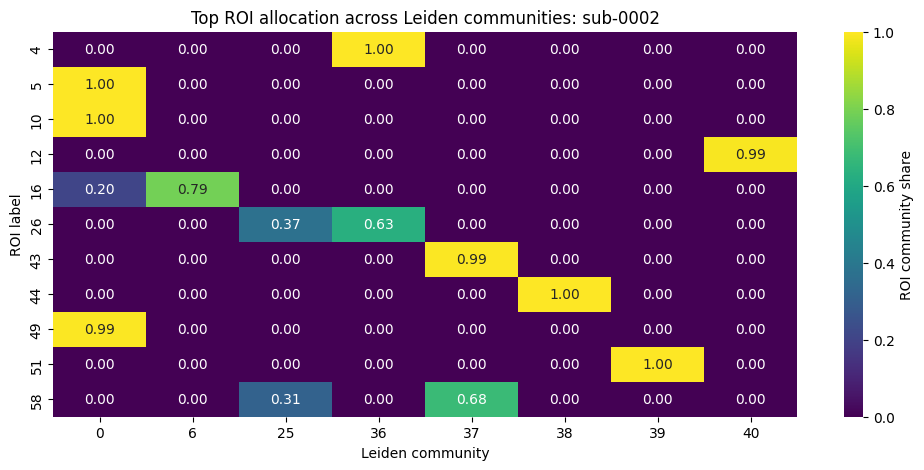

In [10]:

subject_id = "sub-0002"

plot_df = subject_roi_ranks.query("subject_id == @subject_id")

heatmap_data = plot_df.pivot(
    index="roi_label",
    columns="community",
    values="roi_community_share",
).fillna(0)

plt.figure(figsize=(12, 5))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "ROI community share"},
)

plt.xlabel("Leiden community")
plt.ylabel("ROI label")
plt.title(f"Top ROI allocation across Leiden communities: {subject_id}")
plt.show()